In [15]:
import os
import numpy as np
from PIL import Image

TRAIN_DIR = "/kaggle/input/datasets/salader/dogsvscats/train"
IMG_SIZE = (128, 128)
SAMPLE_SIZE = 200 # per class

def load_images(folder, label, n):
    files = os.listdir(folder)[:n]
    data, labels = [], []
    for fname in files:
        img = Image.open(os.path.join(folder, fname)).convert("RGB").resize(IMG_SIZE)
        data.append(np.array(img)); labels.append(label)
    return data, labels

cat_imgs, cat_labels = load_images(os.path.join(TRAIN_DIR, "cats"), "cat", SAMPLE_SIZE)
dog_imgs, dog_labels = load_images(os.path.join(TRAIN_DIR, "dogs"), "dog", SAMPLE_SIZE)
images = np.array(cat_imgs + dog_imgs)
true_labels = cat_labels + dog_labels
print(images.shape)

(400, 128, 128, 3)


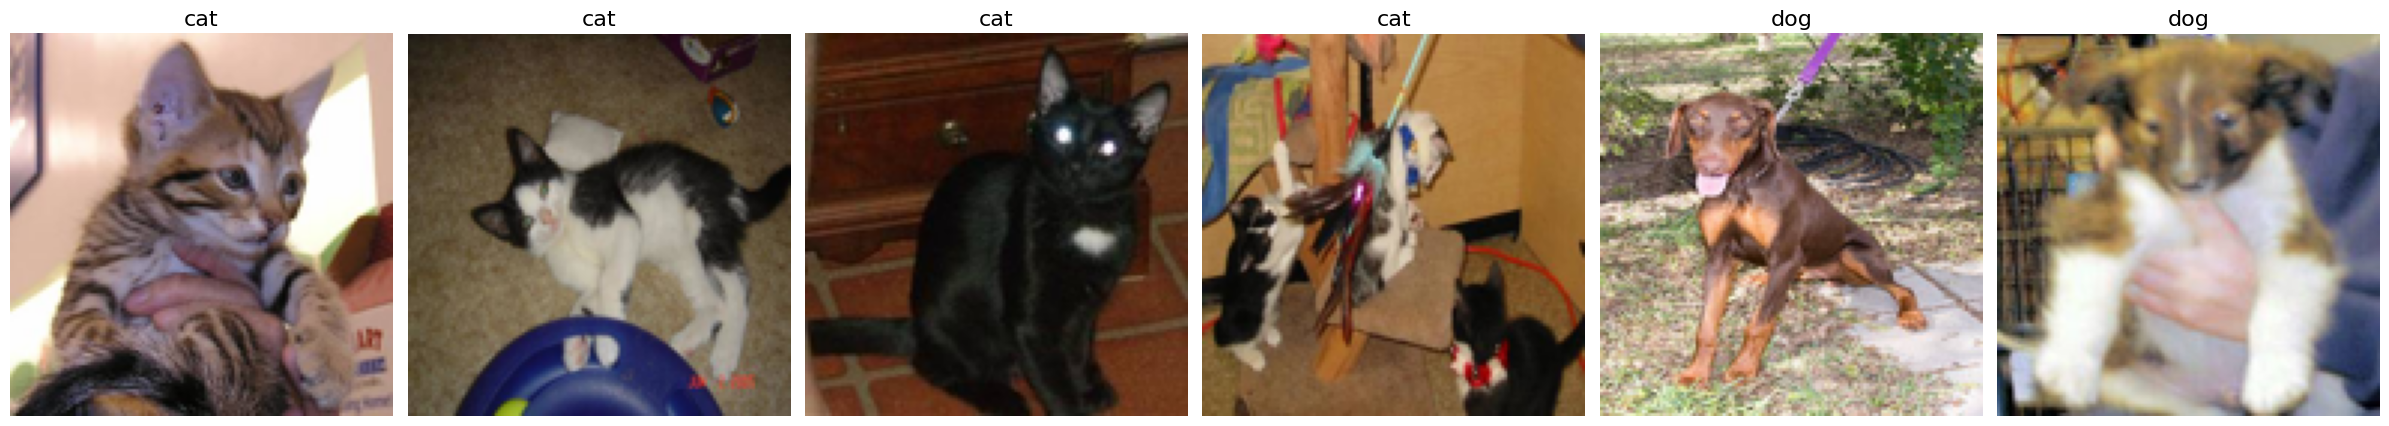

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 6, figsize=(24, 6))

for i in range(6):
    index = i * 65
    axes[i].imshow(images[index])
    axes[i].set_title(true_labels[index], fontsize=16)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [7]:
X = images.reshape(len(images), -1) / 255.0
print(X.shape)

(400, 3072)


In [8]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X)

KMeans(n_clusters=2, n_init=10, random_state=42)

In [9]:
predicted_clusters = kmeans.predict(X)

import pandas as pd

print(pd.Series(predicted_clusters).value_counts())

0    206
1    194
Name: count, dtype: int64


In [10]:
comparison = pd.crosstab(predicted_clusters, true_labels)
print(comparison)

col_0  cat  dog
row_0          
0      107   99
1       93  101


In [18]:
from sklearn.metrics import accuracy_score

cluster0_label = pd.Series(np.array(true_labels)[predicted_clusters == 0]).mode()[0]
cluster1_label = pd.Series(np.array(true_labels)[predicted_clusters == 1]).mode()[0]

predicted_labels = [
    cluster0_label if c == 0 else cluster1_label
    for c in predicted_clusters
]

accuracy = accuracy_score(true_labels, predicted_labels)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.52
Accuracy (%): 52.0


In [22]:
import pandas as pd
from sklearn.metrics import accuracy_score

# Predict clusters
predicted_clusters = kmeans.predict(X)

# Match clusters to Cat/Dog
cluster0_label = pd.Series(np.array(true_labels)[predicted_clusters == 0]).mode()[0]
cluster1_label = pd.Series(np.array(true_labels)[predicted_clusters == 1]).mode()[0]

predicted_labels = [
    cluster0_label if c == 0 else cluster1_label
    for c in predicted_clusters
]

# Create table
results = pd.DataFrame({
    "Actual": true_labels,
    "Predicted": predicted_labels
})

print(results.head(400))

# Accuracy
accuracy = accuracy_score(true_labels, predicted_labels)

print("\nAccuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

    Actual Predicted
0      cat       dog
1      cat       cat
2      cat       cat
3      cat       cat
4      cat       cat
..     ...       ...
395    dog       dog
396    dog       dog
397    dog       cat
398    dog       dog
399    dog       cat

[400 rows x 2 columns]

Accuracy: 0.52
Accuracy (%): 52.0


Training images: (400, 128, 128, 3)
Training labels: 400
X_train: (400, 49152)

Cluster Mapping:
{0: 'cat', 1: 'dog'}

Testing images: (200, 128, 128, 3)
Testing labels: 200

================ TEST RESULTS ================

Actual Predicted  Cluster
   cat       cat        0
   cat       cat        0
   cat       cat        0
   cat       dog        1
   cat       dog        1
   cat       dog        1
   cat       cat        0
   cat       cat        0
   cat       dog        1
   cat       dog        1
   cat       dog        1
   cat       cat        0
   cat       dog        1
   cat       cat        0
   cat       dog        1
   cat       dog        1
   cat       cat        0
   cat       dog        1
   cat       cat        0
   cat       cat        0
   cat       dog        1
   cat       dog        1
   cat       cat        0
   cat       cat        0
   cat       dog        1
   cat       cat        0
   cat       cat        0
   cat       cat        0
   cat       cat       

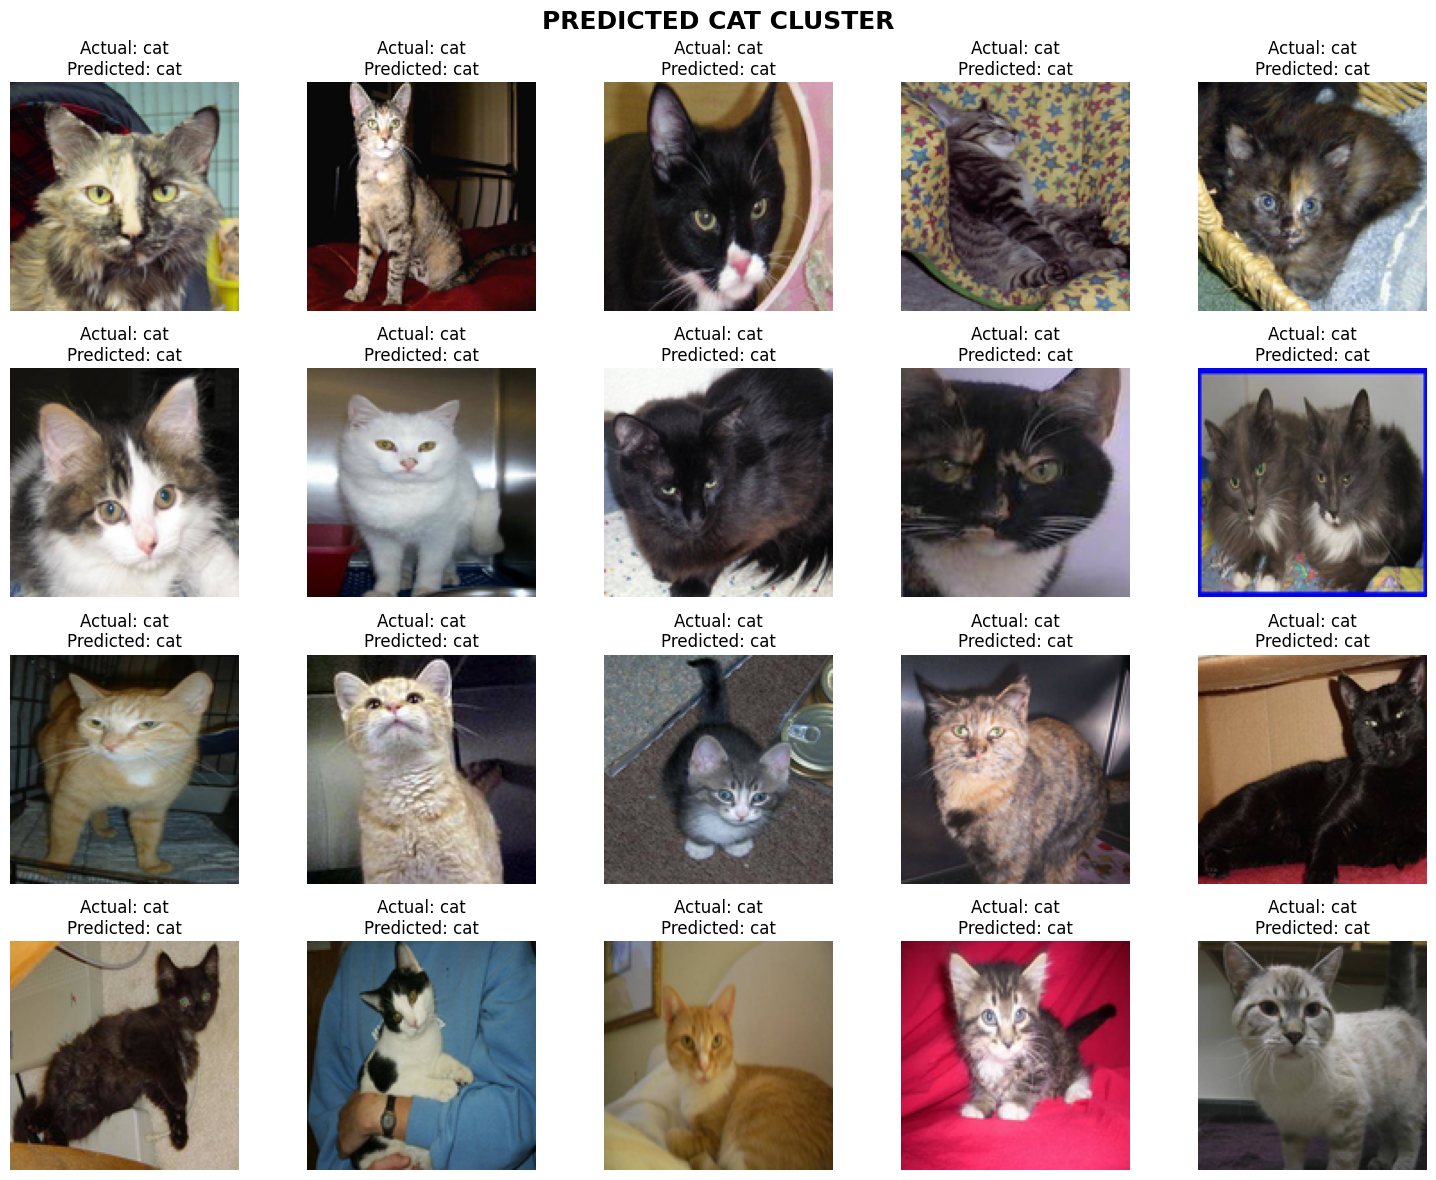


Number of images predicted as DOG: 81


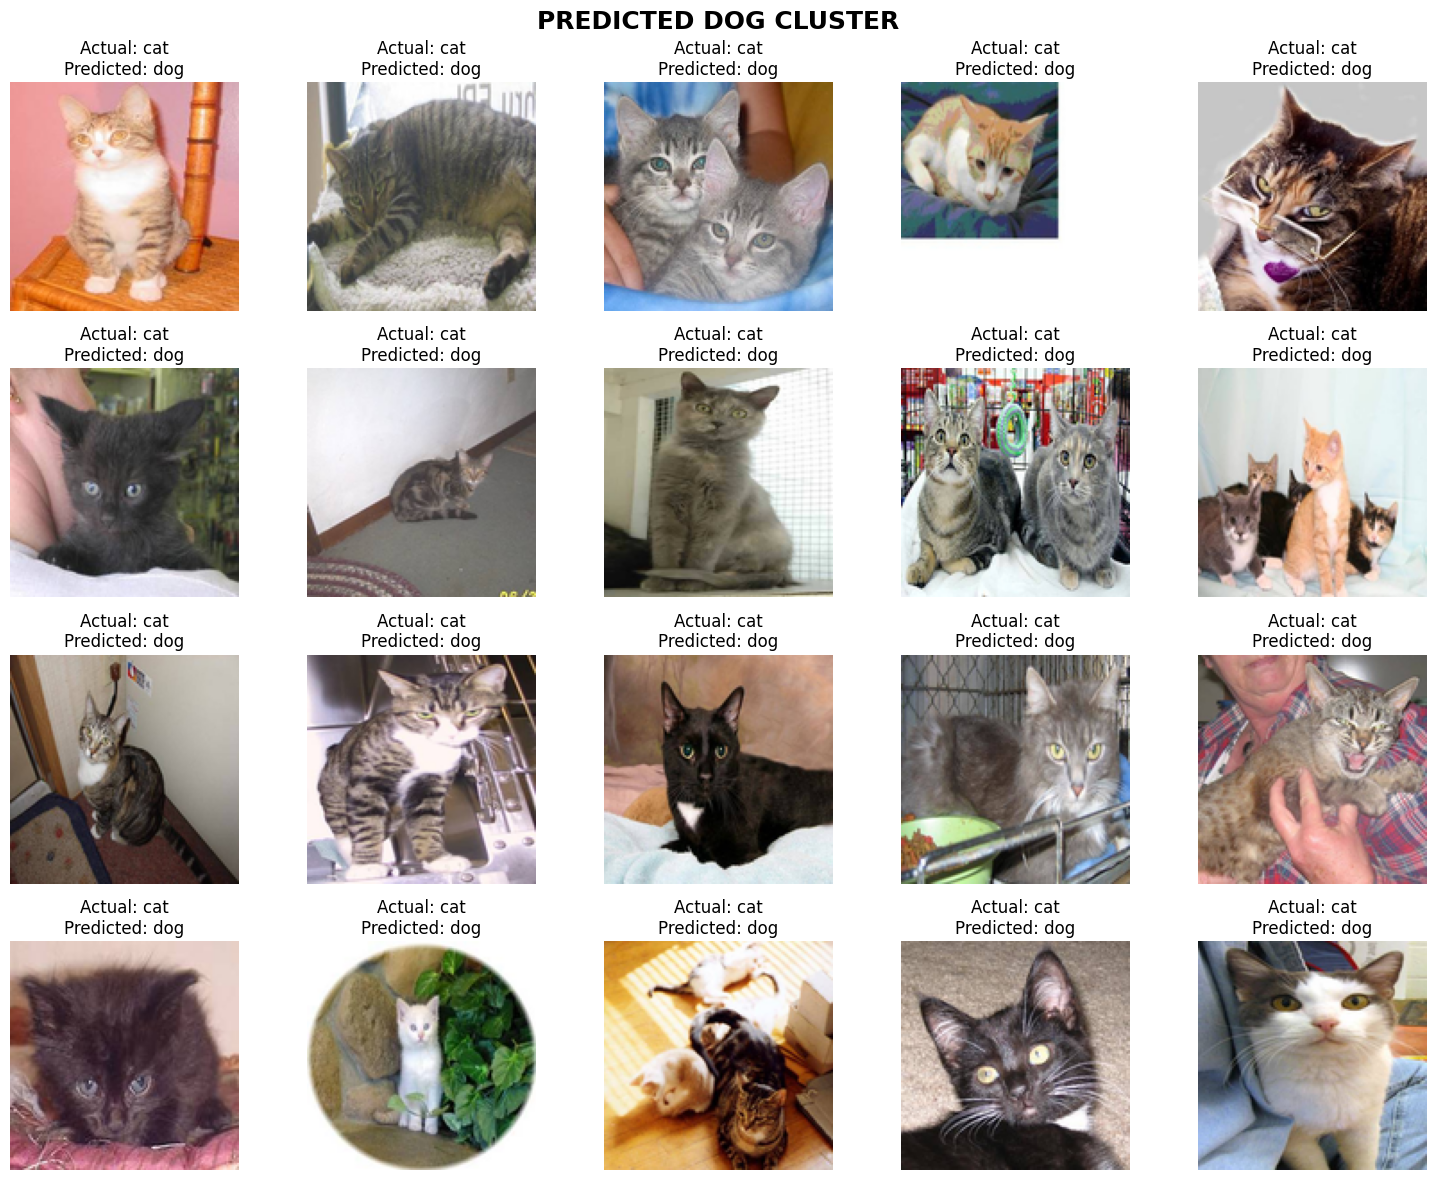


Incorrect predictions: 105


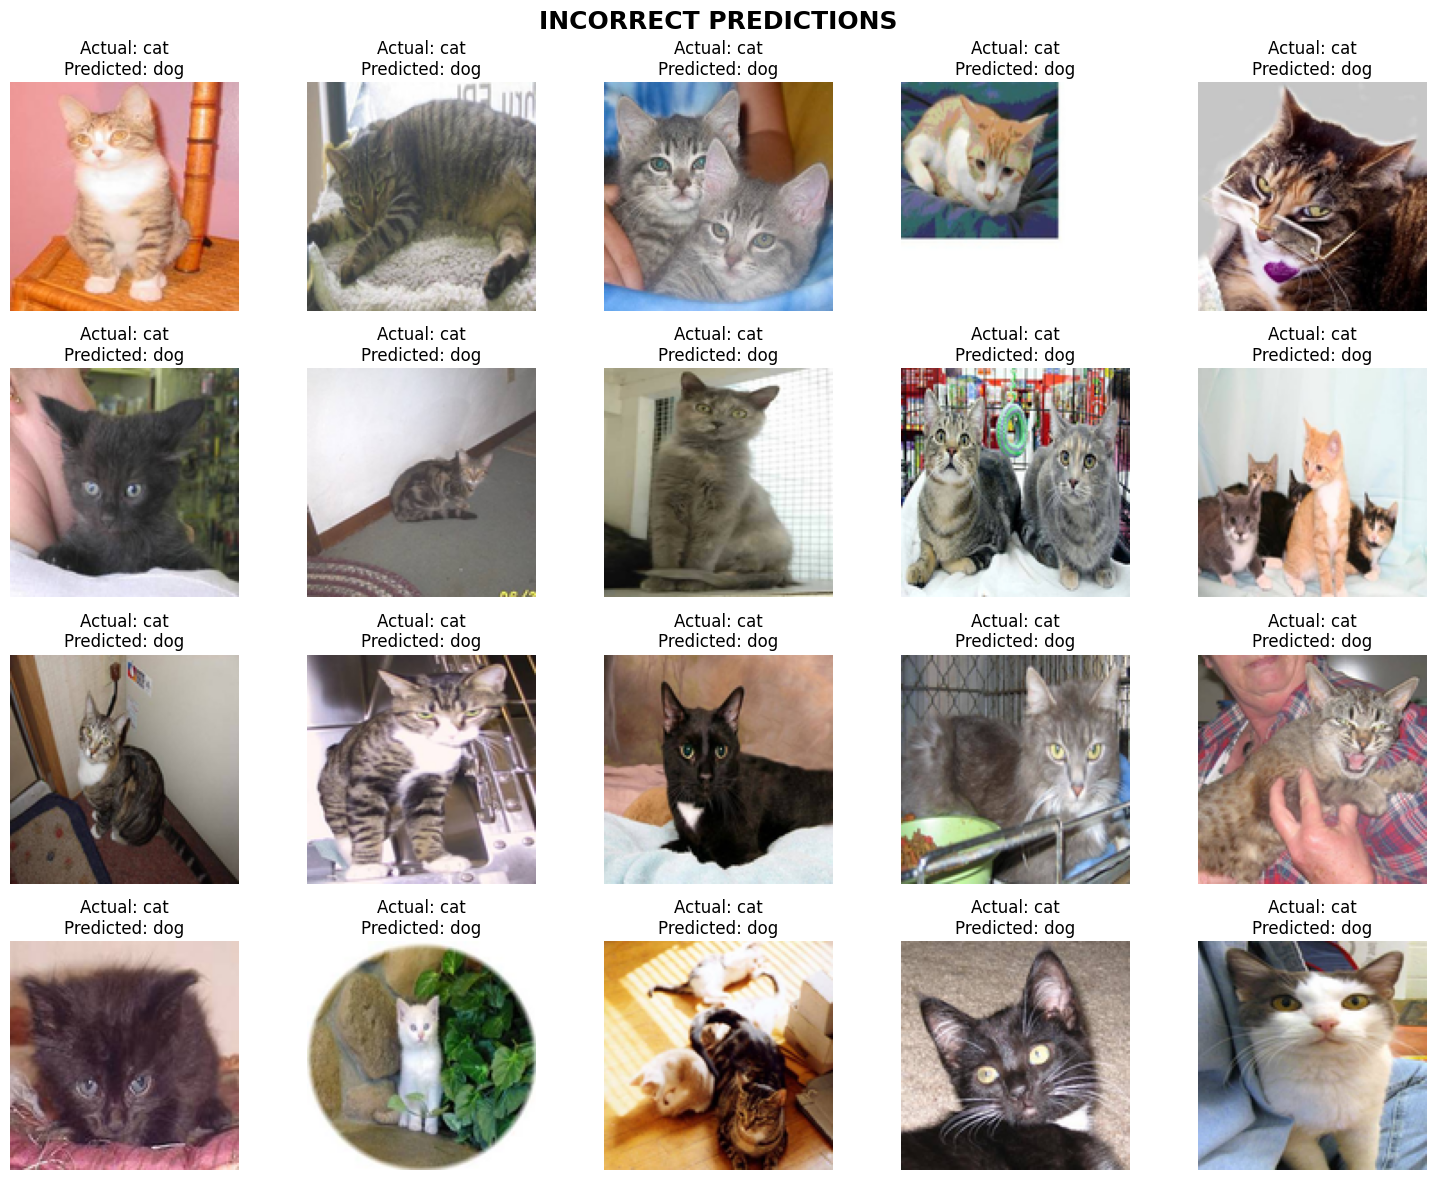

In [23]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score

# ============================================================
# 1. Configuration
# ============================================================

BASE_DIR = "/kaggle/input/datasets/salader/dogsvscats"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR = os.path.join(BASE_DIR, "test")

IMG_SIZE = (128, 128)

TRAIN_SAMPLE_SIZE = 200
TEST_SAMPLE_SIZE = 100


# ============================================================
# 2. Load Images
# ============================================================

def load_images(folder, label, n):
    data = []
    labels = []

    if not os.path.exists(folder):
        print("Folder not found:", folder)
        return data, labels

    files = sorted(os.listdir(folder))

    files = [
        f for f in files
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    files = files[:n]

    for fname in files:
        img_path = os.path.join(folder, fname)

        try:
            img = Image.open(img_path).convert("RGB")

            img = img.resize(
                IMG_SIZE,
                Image.Resampling.LANCZOS
            )

            data.append(np.array(img))
            labels.append(label)

        except Exception as e:
            print("Error:", fname, e)

    return data, labels


# ============================================================
# 3. Load Training Data
# ============================================================

cat_train, cat_train_labels = load_images(
    os.path.join(TRAIN_DIR, "cats"),
    "cat",
    TRAIN_SAMPLE_SIZE
)

dog_train, dog_train_labels = load_images(
    os.path.join(TRAIN_DIR, "dogs"),
    "dog",
    TRAIN_SAMPLE_SIZE
)

train_images = np.array(cat_train + dog_train)
train_labels = np.array(cat_train_labels + dog_train_labels)

print("Training images:", train_images.shape)
print("Training labels:", len(train_labels))


# ============================================================
# 4. Flatten & Normalize Training Images
# ============================================================

X_train = train_images.reshape(
    len(train_images), -1
).astype(np.float32) / 255.0

print("X_train:", X_train.shape)


# ============================================================
# 5. Train K-Means
# ============================================================

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

kmeans.fit(X_train)

train_clusters = kmeans.labels_


# ============================================================
# 6. Determine Cluster Meaning
# ============================================================

cluster_mapping = {}

for cluster in [0, 1]:

    cluster_labels = train_labels[
        train_clusters == cluster
    ]

    cat_count = np.sum(cluster_labels == "cat")
    dog_count = np.sum(cluster_labels == "dog")

    if cat_count > dog_count:
        cluster_mapping[cluster] = "cat"
    else:
        cluster_mapping[cluster] = "dog"


print("\nCluster Mapping:")
print(cluster_mapping)


# ============================================================
# 7. Load Testing Data
# ============================================================

cat_test, cat_test_labels = load_images(
    os.path.join(TEST_DIR, "cats"),
    "cat",
    TEST_SAMPLE_SIZE
)

dog_test, dog_test_labels = load_images(
    os.path.join(TEST_DIR, "dogs"),
    "dog",
    TEST_SAMPLE_SIZE
)

test_images = np.array(cat_test + dog_test)
test_labels = np.array(cat_test_labels + dog_test_labels)

print("\nTesting images:", test_images.shape)
print("Testing labels:", len(test_labels))


# ============================================================
# 8. Prepare Testing Data
# ============================================================

X_test = test_images.reshape(
    len(test_images), -1
).astype(np.float32) / 255.0


# ============================================================
# 9. Predict Clusters
# ============================================================

test_clusters = kmeans.predict(X_test)

predicted_labels = np.array([
    cluster_mapping[cluster]
    for cluster in test_clusters
])


# ============================================================
# 10. Accuracy
# ============================================================

accuracy = accuracy_score(
    test_labels,
    predicted_labels
)


# ============================================================
# 11. Testing Results Table
# ============================================================

results = pd.DataFrame({
    "Actual": test_labels,
    "Predicted": predicted_labels,
    "Cluster": test_clusters
})

print("\n================ TEST RESULTS ================\n")

print(results.to_string(index=False))

print("\n==============================================")
print(f"Testing Accuracy: {accuracy * 100:.2f}%")
print("==============================================")


# ============================================================
# 12. SHOW PREDICTED CAT CLUSTER IMAGES
# ============================================================

cat_indices = np.where(predicted_labels == "cat")[0]

print("\nNumber of images predicted as CAT:",
      len(cat_indices))

num_cat_images = min(20, len(cat_indices))

if num_cat_images > 0:

    cols = 5
    rows = int(np.ceil(num_cat_images / cols))

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(15, 3 * rows)
    )

    axes = np.array(axes).reshape(-1)

    for i in range(num_cat_images):

        index = cat_indices[i]

        axes[i].imshow(test_images[index])

        axes[i].set_title(
            f"Actual: {test_labels[index]}\n"
            f"Predicted: {predicted_labels[index]}"
        )

        axes[i].axis("off")

    for i in range(num_cat_images, len(axes)):
        axes[i].axis("off")

    plt.suptitle(
        "PREDICTED CAT CLUSTER",
        fontsize=18,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 13. SHOW PREDICTED DOG CLUSTER IMAGES
# ============================================================

dog_indices = np.where(predicted_labels == "dog")[0]

print("\nNumber of images predicted as DOG:",
      len(dog_indices))

num_dog_images = min(20, len(dog_indices))

if num_dog_images > 0:

    cols = 5
    rows = int(np.ceil(num_dog_images / cols))

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(15, 3 * rows)
    )

    axes = np.array(axes).reshape(-1)

    for i in range(num_dog_images):

        index = dog_indices[i]

        axes[i].imshow(test_images[index])

        axes[i].set_title(
            f"Actual: {test_labels[index]}\n"
            f"Predicted: {predicted_labels[index]}"
        )

        axes[i].axis("off")

    for i in range(num_dog_images, len(axes)):
        axes[i].axis("off")

    plt.suptitle(
        "PREDICTED DOG CLUSTER",
        fontsize=18,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 14. SHOW INCORRECT PREDICTIONS
# ============================================================

wrong_indices = np.where(
    test_labels != predicted_labels
)[0]

print("\nIncorrect predictions:",
      len(wrong_indices))

num_wrong = min(20, len(wrong_indices))

if num_wrong > 0:

    cols = 5
    rows = int(np.ceil(num_wrong / cols))

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(15, 3 * rows)
    )

    axes = np.array(axes).reshape(-1)

    for i in range(num_wrong):

        index = wrong_indices[i]

        axes[i].imshow(test_images[index])

        axes[i].set_title(
            f"Actual: {test_labels[index]}\n"
            f"Predicted: {predicted_labels[index]}"
        )

        axes[i].axis("off")

    for i in range(num_wrong, len(axes)):
        axes[i].axis("off")

    plt.suptitle(
        "INCORRECT PREDICTIONS",
        fontsize=18,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()